# O que os dados são, antes de qualquer modelo

**Estudo de caso FIESC 02198/2026 — análise exploratória**

Este notebook percorre `banner.csv` e registra o que foi encontrado **antes** de decidir
qualquer coisa. Cada achado aqui virou uma decisão registrada em `docs/decisoes.md`, e a
ordem das seções é a ordem em que os problemas apareceram.

Nenhum deles é exótico. São os problemas normais de um dado industrial real: unidades
duplicadas, anotação humana inconsistente, saturação de registrador, cobertura documental
desigual. O que decide a qualidade da solução é tê-los encontrado *antes*.

In [1]:
import os
import sys
import warnings
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

warnings.filterwarnings("ignore", message=".*IProgress.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.ingestion.eventos import (
    ATRIBUTOS,
    REDUNDANTES,
    SATURACAO_KURTOSIS,
    apenas_defeitos,
    caminho_padrao,
    carregar_eventos,
)
from src.ingestion.rotulos import ALIASES_TIPOGRAFICOS, DEFEITOS, ESTADOS, normalizar
from src.rag.mapeamento import JUSTIFICATIVAS, MAPA

ACENTO, SUCESSO, ALERTA, CRITICO = "#0369A1", "#059669", "#D97706", "#BE123C"
TINTA, SECUNDARIA, SUAVE, GRADE = "#0F172A", "#475569", "#64748B", "#EDEDF1"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.edgecolor": SUAVE, "axes.labelcolor": SECUNDARIA,
    "axes.titlecolor": TINTA, "axes.titleweight": "semibold",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": SECUNDARIA, "ytick.color": SECUNDARIA,
    "grid.color": GRADE, "figure.facecolor": "white",
})


def mil(n: int) -> str:
    return f"{n:,}".replace(",", ".")

## 1. O arquivo, sem tratamento

Vinte e seis colunas. Antes de olhar qualquer distribuição, vale perguntar quantas delas
**são informação**.

In [2]:
bruto = pd.read_csv(caminho_padrao())

print(f"{mil(len(bruto))} linhas · {len(bruto.columns)} colunas\n")
print(bruto.dtypes.to_string())

166.796 linhas · 26 colunas

id                           int64
created_at                  object
z_rms_velocity_in_s        float64
z_rms_velocity_mm_s        float64
temperature_f              float64
temperature_c              float64
x_rms_velocity_in_s        float64
x_rms_velocity_mm_s        float64
z_peak_acceleration_g      float64
x_peak_acceleration_g      float64
z_peak_vel_comp_freq_hz    float64
x_peak_vel_comp_freq_hz    float64
z_rms_acceleration_g       float64
x_rms_acceleration_g       float64
z_kurtosis                 float64
x_kurtosis                 float64
z_crest_factor             float64
x_crest_factor             float64
z_peak_velocity_in_s       float64
z_peak_velocity_mm_s       float64
x_peak_velocity_in_s       float64
x_peak_velocity_mm_s       float64
z_high_freq_rms_accel_g    float64
x_high_freq_rms_accel_g    float64
fault                       object
rpm                        float64


> **Nota sobre o `banner.xlsx`.** O conjunto é distribuído também em Excel, e esse arquivo
> **não deve ser usado**: seus decimais estão corrompidos de forma intermitente — `0.0427`
> gravado como `427.0` —, misturando texto e número na mesma coluna. O CSV é a única fonte
> confiável, e é o que este notebook lê.

## 2. Sete colunas que não são informação

Três grandezas aparecem duas vezes, em unidades diferentes. Isso não é redundância
aproximada — é **conversão de unidade**, e a prova é que a razão entre os pares é constante.

Manter as duas versões alimentaria o modelo com a mesma medida repetida, distorcendo
qualquer cálculo de distância: um atributo duplicado pesa em dobro na similaridade.

In [3]:
pares = [
    ("z_rms_velocity_in_s", "z_rms_velocity_mm_s", "polegada/s ÷ mm/s"),
    ("x_rms_velocity_in_s", "x_rms_velocity_mm_s", "polegada/s ÷ mm/s"),
    ("z_peak_velocity_in_s", "z_peak_velocity_mm_s", "polegada/s ÷ mm/s"),
]

print("razão entre pares de mesma grandeza:\n")
for a, b, rotulo in pares:
    razao = (bruto[a] / bruto[b]).replace([np.inf, -np.inf], np.nan).dropna()
    print(f"  {a:24} {rotulo}  média {razao.mean():.6f}  desvio {razao.std():.2e}")
print(f"\n  1/25,4 (a conversão exata) = {1/25.4:.6f}")

erro_f = (bruto["temperature_f"] - (32 + 1.8 * bruto["temperature_c"])).abs().max()
print(f"\n  temperature_f vs 32 + 1,8·C — erro máximo: {erro_f:.4f} °F (arredondamento)")

print(f"\n{len(REDUNDANTES)} colunas descartadas na ingestão:")
for col in REDUNDANTES:
    print(f"  {col}")
print(f"\nrestam {len(ATRIBUTOS)} atributos numéricos para os modelos.")

razão entre pares de mesma grandeza:

  z_rms_velocity_in_s      polegada/s ÷ mm/s  média 0.039352  desvio 1.97e-05
  x_rms_velocity_in_s      polegada/s ÷ mm/s  média 0.039357  desvio 1.35e-05
  z_peak_velocity_in_s     polegada/s ÷ mm/s  média 0.039357  desvio 1.40e-05

  1/25,4 (a conversão exata) = 0.039370

  temperature_f vs 32 + 1,8·C — erro máximo: 0.0160 °F (arredondamento)

7 colunas descartadas na ingestão:
  z_rms_velocity_in_s
  x_rms_velocity_in_s
  z_peak_velocity_in_s
  x_peak_velocity_in_s
  z_peak_velocity_mm_s
  x_peak_velocity_mm_s
  temperature_f

restam 16 atributos numéricos para os modelos.


## 3. As 151 grafias que descrevem 17 condições

O rótulo `fault` é digitado pelo operador, e ninguém digitou duas vezes igual. São **151
formas distintas** para 17 condições reais.

Esta é a peça de maior valor por linha de código do projeto (ADR-005). Sem ela, o guardrail
recusaria eventos que **têm** documentação, apenas porque o rótulo veio escrito de outro
jeito.

In [4]:
eventos = carregar_eventos()

grafias = eventos.groupby("condicao")["fault"].nunique().sort_values(ascending=False)
print(f"{eventos['fault'].nunique()} grafias → {eventos['condicao'].nunique()} condições\n")
print(grafias.to_string())

151 grafias → 17 condições

condicao
desbalanceado            26
normal                   23
rolamento_outer          14
eccentric_rotor          14
rolamento_ball           12
rolamento_inner          12
cocked_rotor             11
rolamento_combination    11
desalinhado               8
falta_fase                4
ventoinha                 4
teste                     3
motor_desligado           3
polia                     2
correia                   2
acelerando                1
baseline                  1


In [5]:
exemplo = "desbalanceado"
formas = sorted(eventos.loc[eventos["condicao"] == exemplo, "fault"].unique())
print(f'as {len(formas)} formas que o operador usou para "{exemplo}":\n')
for f in formas:
    print(f"  {f}")

as 26 formas que o operador usou para "desbalanceado":

  ddesbalanceado_adxl_0
  dedesbalanceado_adxl_1
  desabalanceado_3
  desbalanceado_1parafuso
  desbalanceado_1parafuso_3
  desbalanceado_2_pos_2
  desbalanceado_3
  desbalanceado_adxl_0
  desbalanceado_adxl_1
  desbalanceado_carga
  desbalanceado_carga_2
  desbalanceado_carga_3
  desbalanceado_carga_3_2
  desbalanceado_novo
  desbalanceado_pos_2
  desbalanceamento
  desbanlanceado_carga_3_2
  new_desabanceado_1
  new_desbalanceado_0
  new_desbalanceado_1
  new_desbalanceado_2
  new_desbalanceado_3
  new_desbalanceado_antigo_0
  new_desbalanceado_antigo_1
  new_desbalanceado_antigo_2
  new_desbalanceado_antigo_3


As variações vêm de quatro origens, e cada uma exigiu um mecanismo diferente:

- **sufixo de sessão** (`_2`, `_carga_3`, `_adxl_0`) — removido por regras aplicadas
  repetidamente até a forma estabilizar;
- **prefixo de lote** (`new_`);
- **abreviação** (`rolamento_comb`, `cocked`, `eccentric`);
- **erro de digitação** — que nenhuma regra alcança e que virou dicionário explícito.

Os erros são declarados um a um de propósito. Uma correção por distância de edição
"consertaria" também rótulos legítimos parecidos entre si, silenciosamente.

In [6]:
print(f"{len(ALIASES_TIPOGRAFICOS)} erros de digitação corrigidos por dicionário:\n")
for errado, certo in sorted(ALIASES_TIPOGRAFICOS.items()):
    print(f"  {errado:28} → {certo}")

10 erros de digitação corrigidos por dicionário:

  cockecocked_adxl_0           → cocked_adxl_0
  ddesbalanceado_adxl_0        → desbalanceado_adxl_0
  dedesbalanceado_adxl_1       → desbalanceado_adxl_1
  desabalanceado_3             → desbalanceado_3
  desbalanceamento             → desbalanceado
  desbanlanceado_carga_3_2     → desbalanceado_carga_3_2
  mortor_desligado_novo        → motor_desligado_novo
  new_desabanceado_1           → new_desbalanceado_1
  new_tes                      → new_teste
  normla_carga_3_3             → normal_carga_3_3


In [7]:
demonstracao = ["cockecocked_adxl_0", "desbanlanceado_carga_3_2", "normla_carga_3_3",
                "new_tes", "rolamento_comb_2", "desbalanceado_1parafuso"]
print("da grafia bruta à forma canônica:\n")
for f in demonstracao:
    condicao = normalizar(f)
    print(f"  {f:28} → {condicao.canonico:22} ({condicao.tipo.value})")

da grafia bruta à forma canônica:

  cockecocked_adxl_0           → cocked_rotor           (defeito)
  desbanlanceado_carga_3_2     → desbalanceado          (defeito)
  normla_carga_3_3             → normal                 (estado)
  new_tes                      → teste                  (estado)
  rolamento_comb_2             → rolamento_combination  (defeito)
  desbalanceado_1parafuso      → desbalanceado          (defeito)


## 4. Nem todo evento é falha

Das 17 condições, **cinco não são defeito**: são estados operacionais da bancada. Tratá-las
como falha faria o sistema prescrever correção para uma máquina desligada.

É a origem do terceiro caminho de resposta (ADR-006). Um sistema com apenas dois — prescreve
ou recusa — responderia "não há procedimento para `normal`", o que é verdade e é inútil.

tipo_condicao
defeito    151064
estado      15732

defeitos: 12 famílias · estados: 5
  acelerando, baseline, motor_desligado, normal, teste


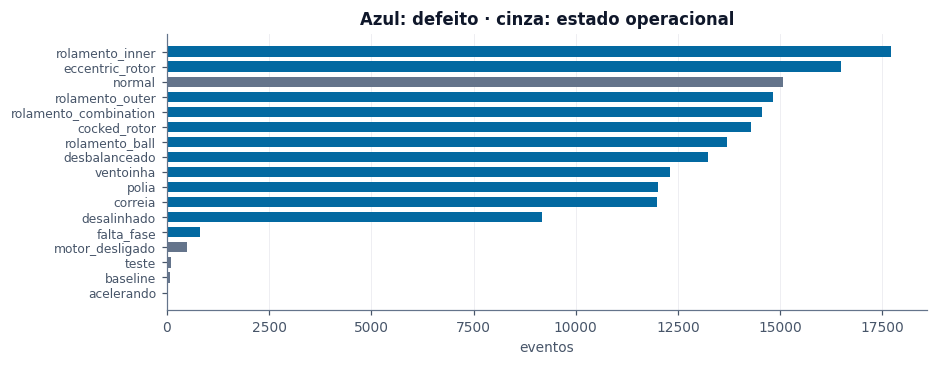

In [8]:
composicao = eventos.groupby("tipo_condicao").size()
print(composicao.to_string())
print(f"\ndefeitos: {len(DEFEITOS)} famílias · estados: {len(ESTADOS)}")
print(f"  {', '.join(sorted(ESTADOS))}")

fig, ax = plt.subplots(figsize=(8.6, 3.4))
contagem = eventos.groupby("condicao").size().sort_values()
cores = [ACENTO if c in DEFEITOS else SUAVE for c in contagem.index]
ax.barh(range(len(contagem)), contagem.values, color=cores, height=0.68)
ax.set_yticks(range(len(contagem)), contagem.index, fontsize=8)
ax.set_xlabel("eventos")
ax.set_title("Azul: defeito · cinza: estado operacional")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 5. A curtose satura

O sensor grava a curtose num registrador de 16 bits. Quando o valor real excede a faixa, ele
registra o teto — **65,535**, que é 2¹⁶ − 1 dividido por mil.

Não é medição: é o registrador dizendo "acima disto eu não sei". Tratar esses valores como
número real levaria um modelo a inferir que dois eventos saturados têm a mesma curtose,
quando o que se sabe é apenas que ambos passaram do teto.

In [9]:
saturados = int(eventos["kurtosis_saturada"].sum())
print(f"eventos com curtose saturada: {saturados} de {mil(len(eventos))} "
      f"({saturados / len(eventos):.3%})")
print(f"valor de saturação: {SATURACAO_KURTOSIS}  (2¹⁶−1 = {2**16 - 1})")
print("\nsão raros — e é justamente por isso que passariam despercebidos.")
print("o índice de similaridade censura esse teto no ajuste, não na consulta:")
print("  recalculá-lo por consulta produzia NaN quando o próprio evento consultado")
print("  estava saturado — defeito encontrado por teste, registrado no ADR-007.")

eventos com curtose saturada: 13 de 166.796 (0.008%)
valor de saturação: 65.535  (2¹⁶−1 = 65535)

são raros — e é justamente por isso que passariam despercebidos.
o índice de similaridade censura esse teto no ajuste, não na consulta:
  recalculá-lo por consulta produzia NaN quando o próprio evento consultado
  estava saturado — defeito encontrado por teste, registrado no ADR-007.


## 6. A cobertura documental é desigual — e a medida certa importa

Doze famílias de defeito, seis procedimentos. Três defeitos não têm documento, por decisão
registrada (ADR-011), e o sistema **recusa** a prescrevê-los.

A pergunta é como medir isso. Por família, a cobertura é 9/12 — 75%. Por **evento**, é outra
coisa, porque as famílias não têm o mesmo peso no histórico.

In [10]:
defeitos = apenas_defeitos(eventos)
por_familia = defeitos.groupby("condicao").size()

documentadas = [c for c in DEFEITOS if MAPA.get(c)]
sem_documento = [c for c in DEFEITOS if not MAPA.get(c)]

eventos_cobertos = int(por_familia[documentadas].sum())
cobertura = eventos_cobertos / len(defeitos)

print(f"famílias documentadas ... {len(documentadas)}/{len(DEFEITOS)}  "
      f"({len(documentadas)/len(DEFEITOS):.1%})")
print(f"eventos cobertos ........ {mil(eventos_cobertos)}/{mil(len(defeitos))}  "
      f"({cobertura:.1%})\n")

print("defeitos sem procedimento, e por quê:\n")
for c in sem_documento:
    print(f"  {c} — {mil(int(por_familia[c]))} eventos")
    print(f"      {JUSTIFICATIVAS[c].strip().splitlines()[0]}\n")

famílias documentadas ... 9/12  (75.0%)
eventos cobertos ........ 121.468/151.064  (80.4%)

defeitos sem procedimento, e por quê:

  falta_fase — 800 eventos
      Trata-se de falha elétrica na alimentação trifásica. Todos os procedimentos disponíveis são de natureza mecânica — rolamentos, alinhamento, balanceamento, correias, polias e rotor.

  eccentric_rotor — 16.497 eventos
      A documentação disponível trata de excentricidade em polias (Doc5), não em rotores. São componentes distintos, com procedimentos de correção distintos: aplicar o procedimento de polia a um rotor excêntrico levaria a intervenção no componente errado.

  ventoinha — 12.299 eventos
      Nenhum dos procedimentos disponíveis trata especificamente de falhas em ventoinhas. Ventiladores aparecem nos documentos apenas como exemplo de equipamento sujeito a outros modos de falha.



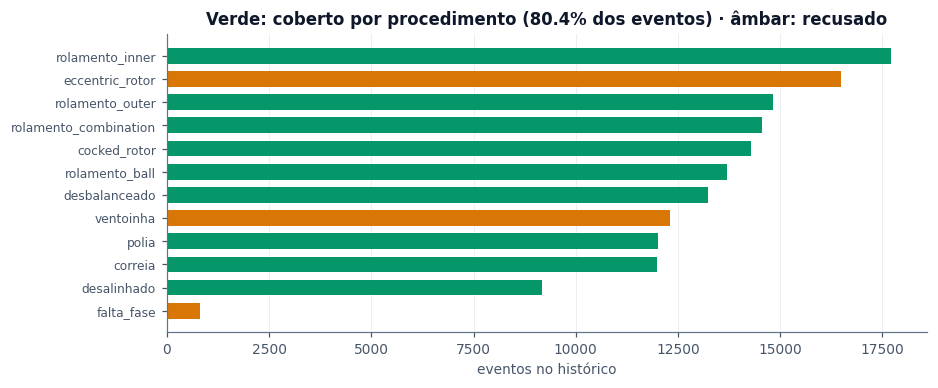

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 3.6))
ordenado = por_familia.sort_values()
cores = [SUCESSO if c in documentadas else ALERTA for c in ordenado.index]
ax.barh(range(len(ordenado)), ordenado.values, color=cores, height=0.68)
ax.set_yticks(range(len(ordenado)), ordenado.index, fontsize=8)
ax.set_xlabel("eventos no histórico")
ax.set_title(f"Verde: coberto por procedimento ({cobertura:.1%} dos eventos) · âmbar: recusado")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

A interface reporta a cobertura **em eventos**, e não em famílias, porque é a resposta à
pergunta que a operação faz: *de todas as vezes em que a máquina falhou, em quantas o sistema
tem o que dizer?* — não *de todos os tipos de falha catalogados, quantos estão documentados?*.

As duas medidas são verdadeiras. A primeira é a útil.

## 7. O evento do enunciado, e seus vizinhos

O enunciado traz um evento de exemplo com `"fault": "cocked_rotor_2"`. Consultá-lo no índice
de similaridade produz o achado que sustenta o ADR-003 — e que uma tabela de acurácia leva
uma página para explicar.

In [12]:
from src.similarity.indice import IndiceSimilaridade

EVENTO = {
    "z_rms_velocity_mm_s": 1.517, "x_rms_velocity_mm_s": 2.0, "temperature_c": 24.69,
    "z_peak_acceleration_g": 0.484, "x_peak_acceleration_g": 0.631,
    "z_peak_vel_comp_freq_hz": 61.0, "x_peak_vel_comp_freq_hz": 61.0,
    "z_rms_acceleration_g": 0.09, "x_rms_acceleration_g": 0.114,
    "z_kurtosis": 2.392, "x_kurtosis": 2.77,
    "z_crest_factor": 3.747, "x_crest_factor": 4.269,
    "z_high_freq_rms_accel_g": 0.129, "x_high_freq_rms_accel_g": 0.147,
    "rpm": 1000.0,
}

indice = IndiceSimilaridade(eventos)
contexto = indice.consultar(EVENTO, vizinhos=10)

print("os 10 vizinhos mais próximos do evento do enunciado:\n")
for v in contexto.vizinhos:
    print(f"  similaridade {v.similaridade:.4f}   {v.condicao:18} ({v.rotulo_bruto})")

print("\ncomposição da vizinhança:")
for o in contexto.ocorrencias:
    print(f"  {o.condicao:18} {o.vizinhos:2} de {len(contexto.vizinhos)} vizinhos · "
          f"{mil(o.ocorrencias_historicas)} ocorrências no histórico")

os 10 vizinhos mais próximos do evento do enunciado:

  similaridade 1.0000   cocked_rotor       (cocked_rotor_2)
  similaridade 0.9739   cocked_rotor       (cocked_rotor_2)
  similaridade 0.8323   cocked_rotor       (cocked_rotor_2)
  similaridade 0.8229   cocked_rotor       (cocked_rotor_2)
  similaridade 0.8056   cocked_rotor       (cocked_rotor_2)
  similaridade 0.8044   eccentric_rotor    (eccentric_rotor)
  similaridade 0.7981   eccentric_rotor    (eccentric_rotor)
  similaridade 0.7979   ventoinha          (ventoinha_2)
  similaridade 0.7941   cocked_rotor       (cocked_rotor_2)
  similaridade 0.7935   ventoinha          (ventoinha_2)

composição da vizinhança:
  cocked_rotor        6 de 10 vizinhos · 14.275 ocorrências no histórico
  eccentric_rotor     2 de 10 vizinhos · 16.497 ocorrências no histórico
  ventoinha           2 de 10 vizinhos · 12.299 ocorrências no histórico


Os vizinhos mais próximos de um evento de `cocked_rotor` **não são todos `cocked_rotor`**.
A vizinhança mistura famílias que, fisicamente, produzem desequilíbrio de rotor por causas
diferentes.

Isso não é falha do índice — é a informação que o dado carrega. As dezesseis grandezas
escalares descrevem *quanto* a máquina vibra, não *por quê*. Separar essas famílias exigiria
análise espectral de envelope, que o conjunto não contém.

E é exatamente por isso que o sistema **mostra os vizinhos em vez de afirmar um
diagnóstico**. A resposta é a lista, com cada vizinho rastreável até seu `id` e sua data:
quem lê decide o quanto ela é conclusiva. Um classificador entregaria um rótulo único e
esconderia essa ambiguidade — que é real e que o técnico precisa ver.

O experimento completo está em
[`01-classificador-e-vazamento.ipynb`](01-classificador-e-vazamento.ipynb).

---

### O que esta exploração determinou

| Achado | Decisão |
| --- | --- |
| 7 colunas são conversão de unidade | descartadas na ingestão (ADR-007) |
| 151 grafias para 17 condições | normalização canônica (ADR-005) |
| 5 condições não são falha | terceiro caminho de resposta (ADR-006) |
| curtose satura em 65,535 | teto censurado no ajuste do índice (ADR-007) |
| cobertura desigual entre famílias | medida em eventos, não em famílias (ADR-011) |
| vizinhança mistura famílias | sem classificador no caminho crítico (ADR-003) |

Nenhuma dessas decisões teria sido tomada olhando apenas o esquema das colunas.